In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
# jax.config.update('jax_default_device', jax.devices('cpu')[0])

# Import your optimization and plotting utilities
from optimization_core import (
    scaled_spdc_jsa_vectorized,
    scaled_spdc_jsa_vectorized_rsvd,
)

from tensorrsvd import ho_rsvd

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Joint spectral amplitude (JSA) of photon number states generated via higher-order spontaneous parametric downconversion (SPDC)

**Phase-mismatch Taylor expansion**

$$
\frac{\ell}{2} \Delta k\left(\delta\omega_1,\delta\omega_2,...,\delta\omega_n\right)=\tau_1 \left(\delta\omega_1+\delta\omega_2+...+\delta\omega_n\right) +\tau_P^2\left(\delta\omega_1+\delta\omega_2+...+\delta\omega_n\right)^2 \\\\-\tau_F^2\left(\delta\omega_1^2+\delta\omega_2^2+...+\delta\omega_n^2\right),

$$

where 

$$\tau_1=\frac{L}{2}\left(\frac{1}{v_{g_{P}}}-\frac{1}{v_{g_{F}}}\right),~\tau_P^2=\frac{L}{4}\beta_{2_P},~\tau_F^2=\frac{L}{4}\beta_{2_F}.$$

$L$ : Length of the nonlinear media.\
$v_{g_{P}},v_{g_{F}}$ : Group velocity of the pump and N-photon modes. \
$\beta_{2_P},\beta_{2_F}$ : Group velocity dispersion of the pump and N-photon modes. \
 


**Phase-mismatch expansion in scaled units**

Defining scaled frequencies $w_i~=~\tau_F~\delta\omega_i$, we have

$$\frac{\ell}{2} \Delta k\left(w_1,~w_2,...,~w_n\right)=\frac{\tau_1}{\tau_F} \left(w_1+~w_2+...+~w_n\right)+\frac{\tau_P^2}{\tau_F^2}\left(w_1+~w_2+...+~w_n\right)^2 \\\\ -\left(w_1^2+w_2^2+...+w_n^2\right),$$

**Pump envelope function in scaled units**

Defining a gaussian pump:

$$\alpha \left(\delta\omega_1,\delta\omega_2,...,\delta\omega_n\right)= \exp \left(-\frac{1}{2}T^2\left(\delta\omega_1+\delta\omega_2+...+\delta\omega_n\right)^2\right)$$

We can now write it in scaled units as

$$\alpha \left(w_1,~w_2,...,~w_n\right)= \exp \left(-\frac{1}{2}\frac{T^2}{\tau_F^2}\left(w_1+w_2+...+w_n\right)^2\right)$$

The module ```scaled_spdc_jsa_vectorized``` provides a fully vectorized implementation of a higher order SPDC Joint Spectral Amplitude (JSA), using a global scaling based on the widest axis of the distribution determined by phase-matching bandwidth $\approx \tau_{F}$. 


### Example evaluation on a grid of points:

The bandwidth of the phase-matching function, $\sigma_{PM}=\sqrt{4 \pi/\ell \beta_{2_F}}$, is  determined by the width of the central peak of the $\text{sinc}(\Delta k~\ell/2)$ function, occurring when $\Delta k~\ell/2=\pi$.

For visualization purposes, the JSA projections and single photon reduced density matrices will be plotted as functions of the variables $\delta\omega_{i}/\sigma_{PM}$, where $i \in {1,2,3}$. This requires a scaling factor applied to the scaled frequencies  $w_{i}/\sqrt{\pi}$.

In [2]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# # Sweep parameters
n_steps = 4  # Number of steps in the sweep
# taup=jnp.linspace(-0.49, 0.99 , n_steps) #b is analogous to the correlation coefficients in the correlation matrix

# Dispersion parameters
ldelk01 = 0  # Phase mismatch at the central frequencies
tau11 = 0  # Group-velocity matching
# taup1=1 # \beta_P << \beta_F -->\beta_P negligible in comparison to \beta_F
taup = jnp.linspace(
    0, 7.5, n_steps
)  # We can also sweep over taup1, which is the parameter that controls the pump bandwidth. This allows us to explore different regimes of pump bandwidth in relation to the phase-matching function.
tauf1 = 1.5  # \beta_F >> \beta_P
T0 = tauf1 / jnp.sqrt(jnp.pi)  # Pump bandwidth


# Geometrical parameters
n_res = 30  # Number of points inside the bandwidth of the phase-matching function in the frequency grid nxnxn
d = 3  # Dimensionality of the problem

# Spectral resolution
sigmapm = (
    jnp.sqrt(jnp.pi) / tauf1
)  # Approximate HWHM of the phase-matching function, measured in terms of the sinc's main lobe width
delw = (
    sigmapm / n_res
)  # The spectral resolution is defined such that a minimum of n discrete points are sampled within each frequency vector over the bandwidth of the phase-matching function, regardless of the specific width of the evaluation function.
# Spectral window
domg = (
    4 * sigmapm
)  # We set the half-width of the frequency window wide enough to sample correctly both the jsa and reduced density matrix
n = int(jnp.ceil(2 * domg / delw)) + 1  # +1 so linspace's actual spacing is <= delw
print(
    n
)  # Note: Always check the frequency vector size, because later we are going to build a 3D grid with it, which greatly affects  the memory usage.
omf = jnp.linspace(-domg, domg, n)

# omf=jnp.arange(-domg,domg,delw)
# n=omf.size
# print(n) # Note: Always check the frequency vector size, because later we are going to build a 3D grid with it, which greatly affects  the memory usage.

# Create N‑dimensional meshgrid
grid = jnp.meshgrid(*([omf] * d), indexing="ij")

241


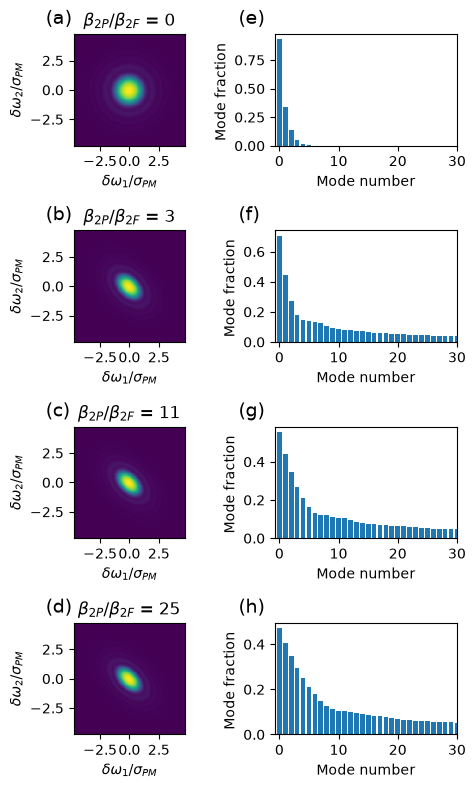

In [3]:
n_col = 2  # Number of columns in the figure
fig, axes = plt.subplots(len(taup), n_col, figsize=(2.5 * n_col, n_col * len(taup)))
axes = np.atleast_2d(axes)

# Generate labels: a, b, c, ...
labels = list(string.ascii_lowercase)

T01 = 0
for i, taup1 in enumerate(taup):
    jsa = scaled_spdc_jsa_vectorized(
        ldelk0=ldelk01, tau1=tau11, taup=taup1, tauf=tauf1, T0=T01
    )  # Returns a callable function that evaluates the JSA on a point or a grid.
    jsa_data = jsa(
        *grid
    )  # Evaluate the JSA on the grid. This is the most memory intensive step, as it creates a large tensor of size (n,n,n) in this case. Always check the size of the grid and the resulting tensor to avoid memory issues.
    jsa_norm = jnp.linalg.norm(jsa_data)

    # Random SVD
    f = scaled_spdc_jsa_vectorized_rsvd(
        ldelk0=ldelk01, tau1=tau11, taup=taup1, tauf=tauf1, domg=domg, T0=T01
    )  # Returns a callable function that evaluates the JSA on a point or a grid.
    rank = 31
    U_list, S_list = ho_rsvd(
        tensor=f,
        tensor_shape=(n,) * d,
        dtype=jnp.float64,
        rank=rank,
        num_oversamples=10,
        num_power_iterations=2,
        num_idxs=d,
        backend="jax",
    )
    s_norm = S_list[0] / jsa_norm

    # jsa_flat=jnp.reshape(jsa_data,(n,n**(d-1)))
    # u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

    jsa_normal = jsa_data / jsa_norm
    jsa_proj = jnp.sum(jnp.square(jnp.abs(jsa_normal)), axis=0)
    ax0 = axes[i, 0]
    im = ax0.pcolor(omf, omf, jsa_proj, rasterized=True)
    ax0.set_box_aspect(1)
    ax0.set_xlabel(r"$\delta\omega_{1}/\sigma_{PM}$")
    ax0.set_ylabel(r"$\delta\omega_{2}/\sigma_{PM}$")
    ax0.set_title(r"$\beta_{2P}/\beta_{2F}$ = " + f"{(taup1**2/tauf1**2):.0f}")

    # compute label index for column-major order
    j = 0
    label_idx = i + j * len(taup)
    # Add label outside the plot
    ax0.text(
        -0.25,
        1.05,
        f"({labels[label_idx]})",
        transform=ax0.transAxes,
        fontsize=14,
        va="bottom",
        ha="left",
    )

    x = np.arange(0, len(s_norm))

    ax1 = axes[i, 1]
    ax1.bar(x, s_norm)
    ax1.set_xlabel(r"Mode number")
    ax1.set_ylabel(r"Mode fraction ")
    ax1.set_xlim(-0.75, 30)

    j = 1
    label_idx = i + j * len(taup)
    # Add label (next letter)
    ax1.text(
        -0.2,
        1.05,
        f"({labels[label_idx]})",
        transform=ax1.transAxes,
        fontsize=14,
        va="bottom",
        ha="left",
    )
    label_idx += 1

    # Clear memory
    del jsa_data, jsa_norm, jsa_proj
    jax.clear_caches()

plt.tight_layout()
plt.savefig("proj_hopdc_mode_decomp.pdf", dpi=300, bbox_inches="tight")
plt.show()